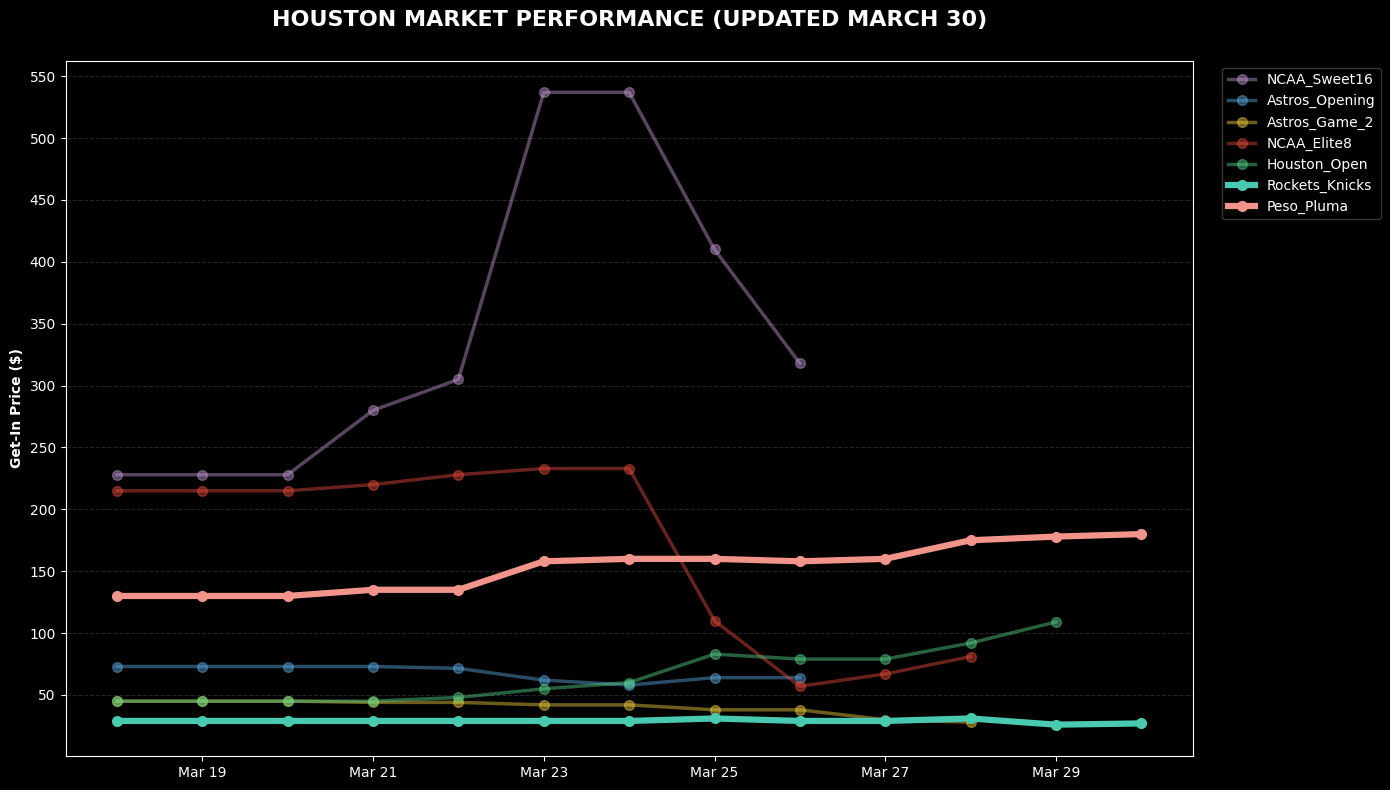


                        🚀 HOUSTON MARKET PERFORMANCE (UPDATED MARCH 30)                        
                                 --- MARKET HISTORY (ENDED) ---                                
EVENT NAME             | START   | FINAL        | TOTAL CHG
-----------------------------------------------------------------------------------------------
NCAA_Sweet16           | $228    | $318    (Final) |    39.5% 📈
Astros_Opening         | $73     | $64     (Final) |   -12.3% 📉
Astros_Game_2          | $45     | $28     (Final) |   -37.8% 📉
NCAA_Elite8            | $215    | $81     (Final) |   -62.3% 📉
Houston_Open           | $45     | $109    (Final) |   142.2% 📈

                                --- ACTIVE / UPCOMING EVENTS ---                               
EVENT NAME             | START   | CURRENT      | TOTAL CHG
-----------------------------------------------------------------------------------------------
Rockets_Knicks         | $29     | $27            |    -6.9% 📉
Peso_Pluma     

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

def run_houston_market_final_push():
    # 1. LIVE DATA ENTRY (13-Day Window: Mar 18 - Mar 30)
    # Balanced to exactly 13 items for Monday, March 30
    houston_trends = {
        # --- MARKET HISTORY (ENDED) ---
        'NCAA_Sweet16':   [228, 228, 228, 280, 305, 537, 537, 410, 318, None, None, None, None],
        'Astros_Opening': [73, 73, 73, 73, 71.5, 62, 58, 64, 64, None, None, None, None],
        'Astros_Game_2':  [45, 45, 45, 44, 44, 42, 42, 38, 38, 30, 28, None, None],
        'NCAA_Elite8':    [215, 215, 215, 220, 228, 233, 233, 110, 57, 67, 81, None, None],
        'Houston_Open':   [45, 45, 45, 45, 48, 55, 60, 83, 79, 79, 92, 109, None],

        # --- ACTIVE / UPCOMING ---
        'Rockets_Knicks': [29, 29, 29, 29, 29, 29, 29, 31, 29, 29, 31, 26, 27],
        'Peso_Pluma':     [130, 130, 130, 135, 135, 158, 160, 160, 158, 160, 175, 178, 180]
    }

    # 2. DATE ALIGNMENT
    target_len = 13
    today = datetime(2026, 3, 30)
    date_list = [(today - timedelta(days=i)).strftime("%Y-%m-%d") for i in range(target_len - 1, -1, -1)]
    df = pd.DataFrame(houston_trends, index=pd.to_datetime(date_list))

    # --- VISUALIZATION (PURE BLACK DARK MODE) ---
    plt.style.use('dark_background')
    fig, ax = plt.subplots(figsize=(14, 8), facecolor='black')
    ax.set_facecolor('black')

    # Neon High-Contrast Palette
    colors = ['#C39BD3', '#5DADE2', '#F4D03F', '#E74C3C', '#58D68D', '#48C9B0', '#F1948A']
    active_list = ['Rockets_Knicks', 'Peso_Pluma']

    for (event, prices), color in zip(houston_trends.items(), colors):
        valid = df[event].dropna()
        is_active = event in active_list

        # Styling: Focus on active, dim historical
        alpha_val = 1.0 if is_active else 0.45
        lw = 4.5 if is_active else 2.5
        z = 5 if is_active else 2

        ax.plot(valid.index, valid.values, marker='o', alpha=alpha_val,
                linewidth=lw, label=event, color=color, markersize=7, zorder=z)

    # Formatting
    ax.yaxis.set_major_locator(ticker.MultipleLocator(50))
    ax.grid(True, which='major', axis='y', alpha=0.15, color='white', linestyle='--')

    # Title (Clean White Text - No Emoji to avoid Glyph Warnings)
    ax.set_title('HOUSTON MARKET PERFORMANCE (UPDATED MARCH 30)',
                 fontsize=16, fontweight='bold', pad=25, color='white')

    ax.set_ylabel('Get-In Price ($)', fontweight='bold', color='white')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

    # Legend Styling
    leg = plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, facecolor='black', edgecolor='#444444')
    for text in leg.get_texts():
        text.set_color('white')

    plt.tight_layout()
    plt.savefig('houston_market_analysis.png', dpi=300, facecolor='black')
    plt.show()

    # --- TERMINAL REPORT ---
    print("\n" + "🚀 HOUSTON MARKET PERFORMANCE (UPDATED MARCH 30)".center(95))
    print("=" * 95)

    # SECTION 1: MARKET HISTORY
    print(f"{'--- MARKET HISTORY (ENDED) ---'.center(95)}")
    print(f"{'EVENT NAME':<22} | {'START':<7} | {'FINAL':<12} | {'TOTAL CHG'}")
    print("-" * 95)

    history_events = ['NCAA_Sweet16', 'Astros_Opening', 'Astros_Game_2', 'NCAA_Elite8', 'Houston_Open']
    for event in history_events:
        prices = df[event].dropna().values
        p_start, p_last = prices[0], prices[-1]
        chg = ((p_last - p_start) / p_start) * 100
        icon = "📉" if chg < 0 else "📈"
        print(f"{event:<22} | ${p_start:<6.0f} | ${p_last:<6.0f} (Final) | {chg:>7.1f}% {icon}")

    # SECTION 2: ACTIVE
    print("\n" + f"{'--- ACTIVE / UPCOMING EVENTS ---'.center(95)}")
    print(f"{'EVENT NAME':<22} | {'START':<7} | {'CURRENT':<12} | {'TOTAL CHG'}")
    print("-" * 95)

    for event in active_list:
        prices = df[event].dropna().values
        p_start, p_last = prices[0], prices[-1]
        chg = ((p_last - p_start) / p_start) * 100
        icon = "📈" if chg > 0 else "📉"
        print(f"{event:<22} | ${p_start:<6.0f} | ${p_last:<6.0f}        | {chg:>7.1f}% {icon}")

    print("=" * 95)

run_houston_market_final_push()